# Toy Gospel Social Network Analysis

In [2]:
#!pip install kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bradystephenson/bibledata")

print("Path to dataset files:", path)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [kagglehub]/3 [kagglehub]


100%|██████████| 11.5M/11.5M [00:00<00:00, 30.8MB/s]

Extracting files...


Path to dataset files: /home/erinbrzusek/.cache/kagglehub/datasets/bradystephenson/bibledata/versions/268


In [8]:
import os
import itertools
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# local directory
DATA_DIR = "/home/erinbrzusek/.cache/kagglehub/datasets/bradystephenson/bibledata/versions/268"

# load datasets
person_verse_path = os.path.join(DATA_DIR, "BibleData-PersonVerse.csv")
person_names_path = os.path.join(DATA_DIR, "BibleData-Person.csv")

df_pv = pd.read_csv(person_verse_path)
df_names = pd.read_csv(person_names_path)

df_pv.head()

,person_verse_id,reference_id,person_label_id,person_id,person_label,person_label_count,person_verse_sequence,person_verse_notes
0,GEN 1:1__YHVH_1_1,GEN 1:1,YHVH_1_1,YHVH_1,G-d,1.0,1,NaN
1,GEN 1:2__YHVH_1_1,GEN 1:2,YHVH_1_1,YHVH_1,G-d,1.0,2,NaN
2,GEN 1:3__YHVH_1_1,GEN 1:3,YHVH_1_1,YHVH_1,G-d,1.0,3,NaN
3,GEN 1:4__YHVH_1_1,GEN 1:4,YHVH_1_1,YHVH_1,G-d,1.0,4,NaN
4,GEN 1:5__YHVH_1_1,GEN 1:5,YHVH_1_1,YHVH_1,G-d,1.0,5,NaN


In [5]:
df_names.head()

,person_id,person_name,surname,unique_attribute,sex,tribe,person_notes,name_instance,person_sequence
0,YHVH_1,YHVH,NaN,"Holy, Holy, Holy (ISA 6:3) and too many others...",male,NaN,NaN,1,1
1,Adam_1,Adam,NaN,first man (1CO 15:45),male,NaN,NaN,1,2
2,Eve_1,Eve,NaN,"first woman, created from Adam (GEN 2:22)",female,NaN,NaN,1,3
3,Cain_1,Cain,NaN,"first son of Adam (GEN 4:1), cursed from the g...",male,NaN,NaN,1,4
4,Abel_1,Abel,NaN,"son of Adam(GEN 4:2), first person murdered (G...",male,NaN,NaN,1,5


Nodes: 155
Edges: 419

Top 5 Most Central Characters:
- YHVH: 0.305
- Joseph: 0.149
- Simon: 0.130
- Mary: 0.110
- Philip: 0.110

Network Assortativity Coefficient: 0.0050


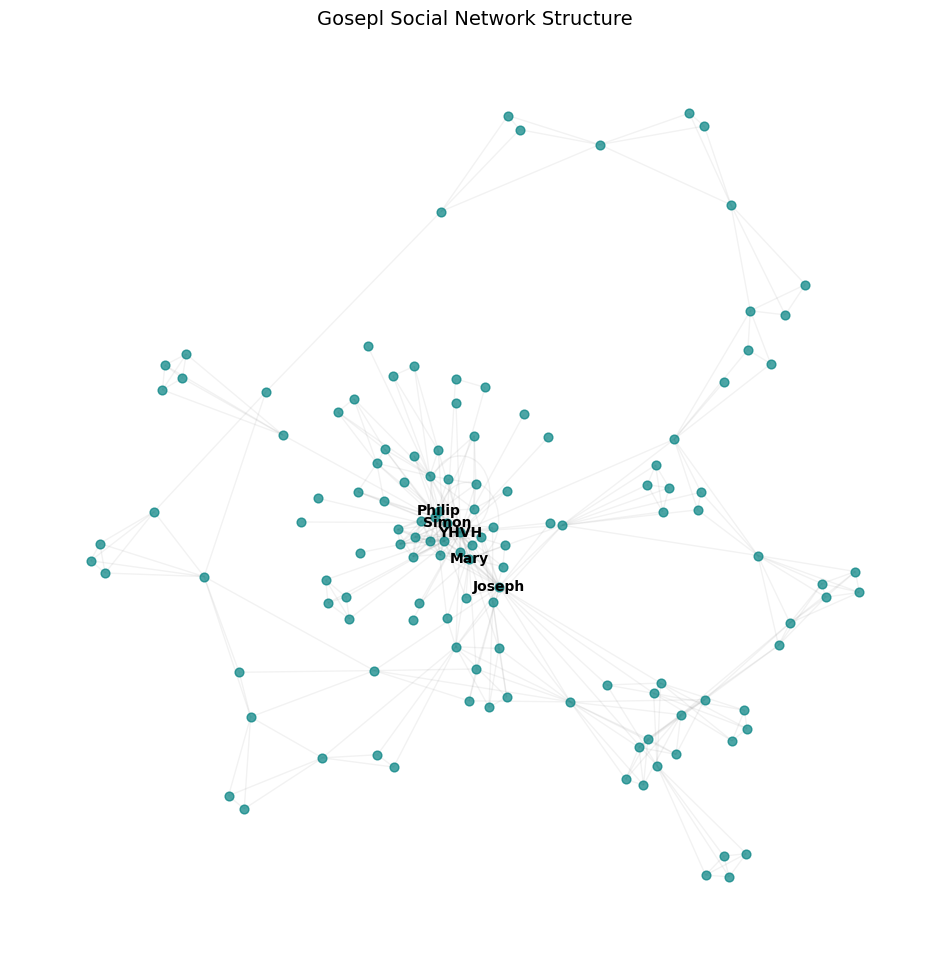

In [11]:
# match person id to names
name_map = dict(zip(df_names['person_id'], df_names['person_name']))
# filter for gospels
gospel_abbreviations = ['MAT', 'MRK', 'LUK', 'JHN']
# split on book names
df_pv['book_abbr'] = df_pv['reference_id'].str.split(' ').str[0]
df_gospels = df_pv[df_pv['book_abbr'].isin(gospel_abbreviations)].copy()

verse_groups = df_gospels.groupby(['reference_id'])['person_id'].apply(list)

# initialize empty weighted graph
G = nx.Graph()

# edges using combinations w/in verse
for characters in verse_groups:
    if len(characters) > 1:
        # all unique pairs
        pairs = itertools.combinations(set(characters), 2)
        for p1, p2 in pairs:
            name1 = name_map.get(p1, p1)
            name2 = name_map.get(p2, p2)
            
            # edge calculations
            if G.has_edge(name1, name2):
                G[name1][name2]['weight'] += 1
            else:
                G.add_edge(name1, name2, weight=1)

# eda
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

# centrality
degree_cent = nx.degree_centrality(G)
top_nodes = sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nTop 5 Most Central Characters:")
for name, cent in top_nodes:
    print(f"- {name}: {cent:.3f}")

# assortativity
assortativity = nx.degree_assortativity_coefficient(G)
print(f"\nNetwork Assortativity Coefficient: {assortativity:.4f}")

plt.figure(figsize=(12, 12))
main_component = G.subgraph(max(nx.connected_components(G), key=len))

pos = nx.spring_layout(main_component, k=0.15, seed=42)
nx.draw_networkx_nodes(main_component, pos, node_size=40, node_color='teal', alpha=0.7)
nx.draw_networkx_edges(main_component, pos, alpha=0.1, edge_color='gray')

top_labels = {name: name for name, _ in top_nodes if name in main_component}
nx.draw_networkx_labels(main_component, pos, labels=top_labels, font_size=10, font_weight='bold')

plt.title("Gosepl Social Network Structure", fontsize=14)
plt.axis('off')
plt.show()